In [5]:
import numpy as np
!pip install matplotlib pandas numpy scikit-learn
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_curve, roc_auc_score, precision_recall_curve, auc
!pip install xgboost lightgbm

In [6]:
df = pd.read_csv('train.csv')
df.head(5)
print(df.shape)
df = df.drop("id", axis=1)
print(df.shape)

(630000, 15)
(630000, 14)


In [7]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df['Heart Disease'] = encoder.fit_transform(df[['Heart Disease']])
df.head(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1.0
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0.0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0.0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0.0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1.0


In [8]:
#checking for null values
df.isnull().sum()
df.head(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1.0
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0.0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0.0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0.0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1.0


Text(0.5, 1.0, 'Blood Pressure vs Heart Disease')

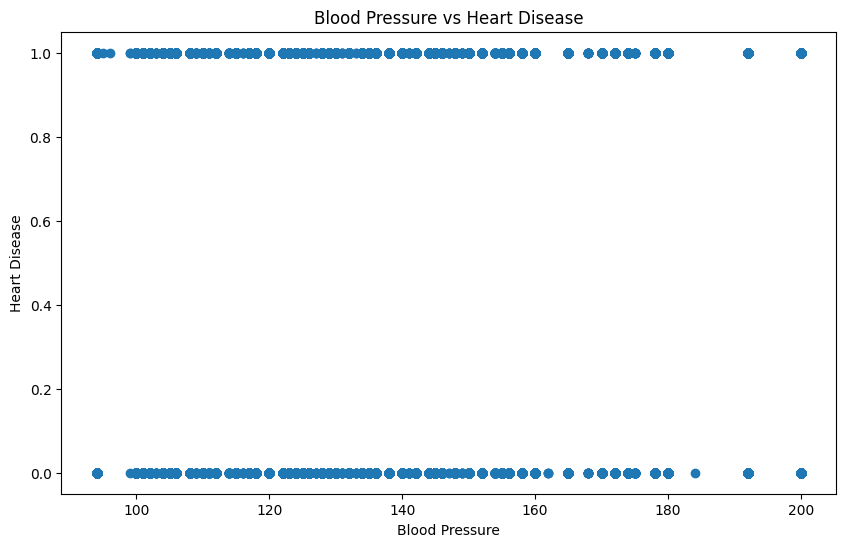

In [9]:
# plotting 
plt.figure(figsize=(10,6))
plt.scatter(df['BP'], df['Heart Disease'])
plt.xlabel('Blood Pressure')
plt.ylabel('Heart Disease')
plt.title('Blood Pressure vs Heart Disease')

In [10]:
from sklearn.model_selection import train_test_split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
625149,54,1,4,110,274,0,0,125,1,0.4,1,0,7
276435,59,0,3,145,197,0,2,179,0,0.0,3,0,3
43949,64,0,4,160,204,0,0,125,0,0.0,2,0,7
280523,51,0,3,125,248,0,0,188,0,0.0,1,0,3
619977,64,0,4,130,204,0,2,138,0,0.0,1,0,3


In [11]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled[:5]


array([[-0.01652147,  0.631521  ,  0.80650941, -1.36762143,  0.86216587,
        -0.29492763, -0.98279102, -1.4567508 ,  1.62960658, -0.33278621,
        -0.83643268, -0.56487167,  1.22106956],
       [ 0.58890684, -1.58347861, -0.36813765,  0.96995128, -1.42524515,
        -0.29492763,  1.01963324,  1.36882066, -0.61364504, -0.75471734,
         2.83198806, -0.56487167, -0.83031362],
       [ 1.19433516, -1.58347861,  0.80650941,  1.97176816, -1.21729869,
        -0.29492763, -0.98279102, -1.4567508 , -0.61364504, -0.75471734,
         0.99777769, -0.56487167,  1.22106956],
       [-0.37977845, -1.58347861, -0.36813765, -0.36580455,  0.08979332,
        -0.29492763, -0.98279102,  1.83974924, -0.61364504, -0.75471734,
        -0.83643268, -0.56487167, -0.83031362],
       [ 1.19433516, -1.58347861,  0.80650941, -0.0318656 , -1.21729869,
        -0.29492763,  1.01963324, -0.77652063, -0.61364504, -0.75471734,
        -0.83643268, -0.56487167, -0.83031362]])

In [12]:
## Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc.fit(X_train_scaled, y_train)
y_prob_dtc = dtc.predict_proba(X_test_scaled)[:, 1] # getting probabilities for the positive class
print(np.unique(y_prob_dtc))

threshold = [0.3, 0.4, 0.5, 0.6, 0.7]
max_recall_score_value = 0
best_threshold = 0

for threshold in threshold:
  y_pred_dtc = (y_prob_dtc >= threshold).astype(int) 
  print(f"--------Threshold--------: {threshold}")
  print("Accuracy:", accuracy_score(y_test, y_pred_dtc))
  print("Classification Report:")
  print(classification_report(y_test, y_pred_dtc))
  print("Confusion Matrix:")
  print(confusion_matrix(y_test, y_pred_dtc))
  recall_score_value = recall_score(y_test, y_pred_dtc)
  print(f"RECALL FOR THRESHOLD {threshold}: {recall_score_value}")
  max_recall_score_value = max(max_recall_score_value, recall_score_value)
  if recall_score_value == max_recall_score_value:
    best_threshold = threshold

print("Best Threshold:", best_threshold)

[0. 1.]
--------Threshold--------: 0.3
Accuracy: 0.8242777777777778
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84     69564
         1.0       0.80      0.81      0.80     56436

    accuracy                           0.82    126000
   macro avg       0.82      0.82      0.82    126000
weighted avg       0.82      0.82      0.82    126000

Confusion Matrix:
[[58266 11298]
 [10843 45593]]
RECALL FOR THRESHOLD 0.3: 0.8078708625699907
--------Threshold--------: 0.4
Accuracy: 0.8242777777777778
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84     69564
         1.0       0.80      0.81      0.80     56436

    accuracy                           0.82    126000
   macro avg       0.82      0.82      0.82    126000
weighted avg       0.82      0.82      0.82    126000

Confusion Matrix:
[[58266 11298]
 [10843 45593]]
RECALL FOR THRESHOLD 0.4: 0.8

ACCURACY : 0.8257
RECALL : 0.8077 
F1 SCORE : 0.81
for all threshold values

In [13]:
## with post pruning
## Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    X_train_scaled, y_train
)

ccp_alphas = path.ccp_alphas[::1000]

best_alpha = None
best_score = 0

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train_scaled, y_train)
    score = clf.score(X_test_scaled, y_test)
    print(f"Alpha: {alpha:.5f}, Score: {score:.5f}")  

    if score > best_score:
        best_score = score
        best_alpha = alpha

print(f"Best alpha: {best_alpha:.5f}, Best score: {best_score:.5f}")

dtc = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dtc.fit(X_train_scaled, y_train)

y_pred_dtc = dtc.predict(X_test_scaled)
print("Final Test Accuracy:", accuracy_score(y_test, y_pred_dtc))
print("Classification Report:")
print(classification_report(y_test, y_pred_dtc))
print(f"RECALL FOR BEST ALPHA {best_alpha}: {recall_score(y_test, y_pred_dtc)}")
print(f"F1 SCORE FOR BEST ALPHA {best_alpha}: {f1_score(y_test, y_pred_dtc)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtc))


Alpha: 0.00000, Score: 0.82428
Alpha: 0.00000, Score: 0.82740
Alpha: 0.00000, Score: 0.83045
Alpha: 0.00000, Score: 0.83297
Alpha: 0.00000, Score: 0.83546
Alpha: 0.00000, Score: 0.83648
Alpha: 0.00000, Score: 0.83860
Alpha: 0.00000, Score: 0.83992
Alpha: 0.00000, Score: 0.84212
Alpha: 0.00000, Score: 0.84500
Alpha: 0.00000, Score: 0.84748
Alpha: 0.00000, Score: 0.85106
Alpha: 0.00000, Score: 0.85338
Alpha: 0.00000, Score: 0.85644
Alpha: 0.00000, Score: 0.85744
Alpha: 0.00000, Score: 0.85965
Alpha: 0.00000, Score: 0.86263
Alpha: 0.00000, Score: 0.86438
Alpha: 0.00000, Score: 0.86621
Alpha: 0.00000, Score: 0.86846
Alpha: 0.00000, Score: 0.87198
Alpha: 0.00000, Score: 0.87568
Alpha: 0.00001, Score: 0.88080
Alpha: 0.00029, Score: 0.87190
Best alpha: 0.00001, Best score: 0.88080
Final Test Accuracy: 0.8808015873015873
Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.90      0.89     69564
         1.0       0.87      0.86      0.87

WITH PRUNING : Best Alpha : 0.00001, Accuracy score : 0.87999, F1 SCORE : 0.8650, RECALL : 0.8584

In [14]:
## Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    min_samples_split=50,
    class_weight={0:1, 1:1.3},
    random_state=42,
    n_jobs=-1
)

rfc.fit(X_train_scaled, y_train)
y_prob_rfc = rfc.predict_proba(X_test_scaled)[:, 1] # getting probabilities for the positive class
print(np.unique(y_prob_rfc))

[0.00719874 0.00752227 0.00756124 ... 0.99812109 0.99816063 0.99817395]


In [15]:
## using ROC-AUC to find the best threshold
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rfc)
J = tpr - fpr
ix = np.argmax(J)
best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)

y_pred_rfc_roc = (y_prob_rfc >= best_threshold).astype(int)

best_accuracy_score_rfc = accuracy_score(y_test, y_pred_rfc_roc)
print("Random Forest Accuracy (Optimized):",
      best_accuracy_score_rfc)
print("Classification Report:")
print(classification_report(y_test, y_pred_rfc_roc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rfc_roc))
best_recall_score_value_rfc = recall_score(y_test, y_pred_rfc_roc)
print(f"Best Recall Score: {best_recall_score_value_rfc}")
best_f1_score_value_rfc = f1_score(y_test, y_pred_rfc_roc)
print(f"Best F1 Score: {best_f1_score_value_rfc}")


Best Threshold: 0.5273959536965185
Random Forest Accuracy (Optimized): 0.884531746031746
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90     69564
         1.0       0.87      0.87      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000

Confusion Matrix:
[[62149  7415]
 [ 7134 49302]]
Best Recall Score: 0.8735913246863704
Best F1 Score: 0.8714218801092326


SINCE DATASET IS NOT SO SMALL, SO NOT GOING TO USE PCA AND SVM.

In [16]:
## XGBoost Classifier
import xgboost as xgb
clf_xgb = xgb.XGBClassifier(n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss')

clf_xgb.fit(X_train_scaled, y_train)
y_prob_xgb = clf_xgb.predict_proba(X_test_scaled)[:, 1]
print(np.unique(y_prob_xgb))

/home/krishanu/DATA_MINING_IN_MEDICAL_INFORMATICS/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:09:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0.0012544  0.00127534 0.0015766  ... 0.9990683  0.99907696 0.9990941 ]


CHOSEN THRESHOLD : 0.35, F1 SCORE : 0.8713, RECALL : 0.9111, ACCURACY : 0.876

In [17]:
## using ROC-AUC to find the best threshold
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
J = tpr - fpr
ix = np.argmax(J)
best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)

y_pred_xgb_roc = (y_prob_xgb >= best_threshold).astype(int)

best_accuracy_score_xgb = accuracy_score(y_test, y_pred_xgb_roc)
print("XGBoost Accuracy (Optimized):",
      best_accuracy_score_xgb)
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_roc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_roc))
best_recall_score_value_xgb = recall_score(y_test, y_pred_xgb_roc)
print(f"Best Recall Score: {best_recall_score_value_xgb}")
best_f1_score_value_xgb = f1_score(y_test, y_pred_xgb_roc)
print(f"Best F1 Score: {best_f1_score_value_xgb}")

Best Threshold: 0.4426140785217285
XGBoost Accuracy (Optimized): 0.8853888888888889
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90     69564
         1.0       0.86      0.88      0.87     56436

    accuracy                           0.89    126000
   macro avg       0.88      0.89      0.88    126000
weighted avg       0.89      0.89      0.89    126000

Confusion Matrix:
[[61675  7889]
 [ 6552 49884]]
Best Recall Score: 0.8839038911333191
Best F1 Score: 0.8735563747165285


XGBoost ROC-AUC: 0.9541870386365966


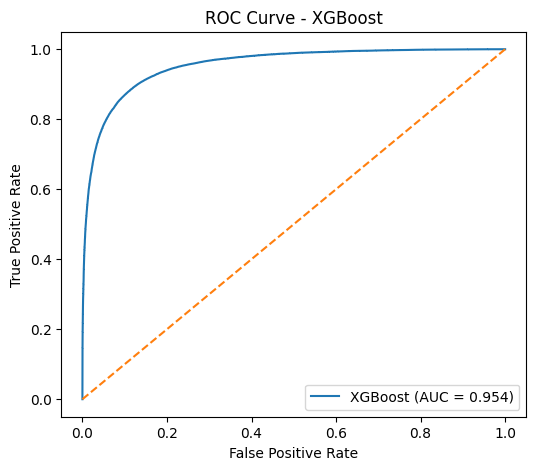

In [18]:
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost ROC-AUC:", xgb_roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {xgb_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


XGBoost Precision-Recall AUC: 0.947


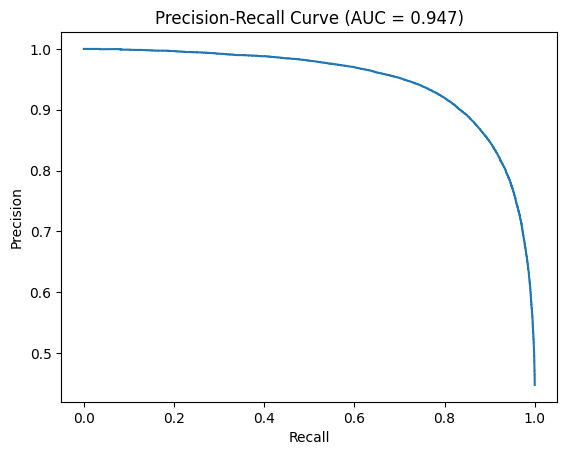

In [19]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc = auc(recall, precision)
print(f"XGBoost Precision-Recall AUC: {pr_auc:.3f}")

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.3f})")
plt.show()

In [20]:
## finetuning the XGBoost Classifier with GridSearchCV
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC:", grid_search.best_score_)

best_xgb_clf = grid_search.best_estimator_

best_xgb_clf.fit(X_train, y_train)
y_prob_xgb_best = best_xgb_clf.predict_proba(X_test)[:,1]


Fitting 5 folds for each of 108 candidates, totalling 540 fits


/home/krishanu/DATA_MINING_IN_MEDICAL_INFORMATICS/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:09:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/krishanu/DATA_MINING_IN_MEDICAL_INFORMATICS/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:09:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/krishanu/DATA_MINING_IN_MEDICAL_INFORMATICS/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:09:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/krishanu/DATA_MINING_IN_MEDICAL_INFORMATICS/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:09:32] WARNING: /__w/xgboost/xgbo

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1}
Best ROC-AUC: 0.9552985233117385


/home/krishanu/DATA_MINING_IN_MEDICAL_INFORMATICS/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:19:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_best))

## using ROC-AUC to find the best threshold
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb_best)
J = tpr - fpr
ix = np.argmax(J)
best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)

y_pred_xgb_best_roc = (y_prob_xgb_best >= best_threshold).astype(int)

best_accuracy_score_xgb_best = accuracy_score(y_test, y_pred_xgb_best_roc)
print("XGBoost Accuracy (Optimized):",
      best_accuracy_score_xgb_best)
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_best_roc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_best_roc))
best_recall_score_value_xgb = recall_score(y_test, y_pred_xgb_best_roc)
print(f"Best Recall Score: {best_recall_score_value_xgb}")
best_f1_score_value_xgb = f1_score(y_test, y_pred_xgb_best_roc)
print(f"Best F1 Score: {best_f1_score_value_xgb}")


Test ROC-AUC: 0.9551569013470653
Best Threshold: 0.4459044635295868
XGBoost Accuracy (Optimized): 0.887
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90     69564
         1.0       0.87      0.88      0.88     56436

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

Confusion Matrix:
[[61866  7698]
 [ 6540 49896]]
Best Recall Score: 0.8841165213693387
Best F1 Score: 0.8751381215469614


XGBoost ROC-AUC: 0.9551569013470653


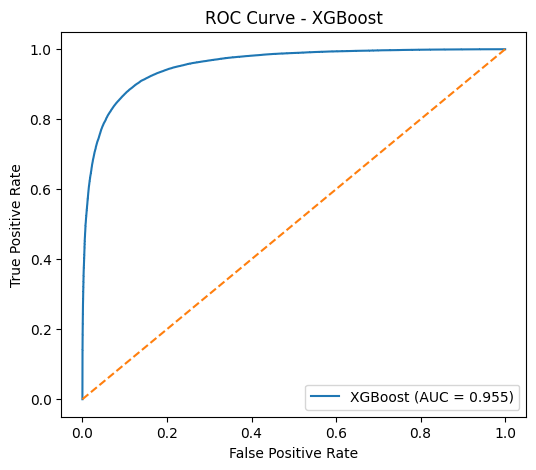

In [22]:
xgb_best_roc_auc = roc_auc_score(y_test, y_prob_xgb_best)
print("XGBoost ROC-AUC:", xgb_best_roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb_best)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {xgb_best_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


XGBoost Precision-Recall AUC: 0.948


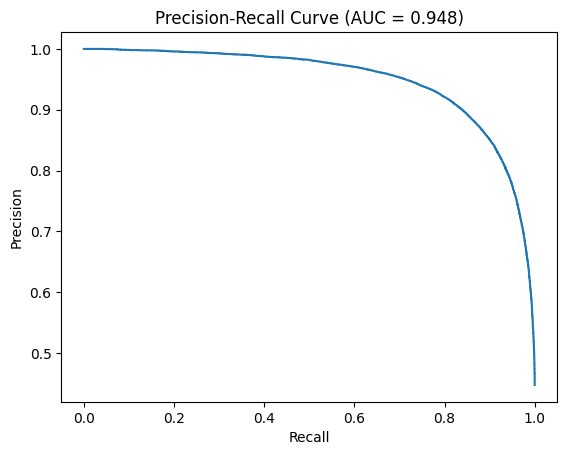

In [23]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb_best)
pr_auc = auc(recall, precision)
print(f"XGBoost Precision-Recall AUC: {pr_auc:.3f}")

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.3f})")
plt.show()

ON APPLYING GRIDSEARCHCV : ROC_AUC SCORE, RECALL, PRECISION AND ACCURACY HAVEN'T INCREASED MUCH.

In [24]:
## LightGBM Classifier
import lightgbm as lgb
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_clf.fit(X_train, y_train)
y_prob_lgb = lgb_clf.predict_proba(X_test)[:, 1]
print(np.unique(y_prob_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 226018, number of negative: 277982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 417
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448448 -> initscore=-0.206942
[LightGBM] [Info] Start training from score -0.206942
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [25]:
## using ROC-AUC to find the best threshold
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgb)
J = tpr - fpr
ix = np.argmax(J)
best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)

y_pred_lgb_roc = (y_prob_lgb >= best_threshold).astype(int)

best_accuracy_score_lgb = accuracy_score(y_test, y_pred_lgb_roc)
print("LightGBM Accuracy (Optimized):",
      best_accuracy_score_lgb)
print("Classification Report:")
print(classification_report(y_test, y_pred_lgb_roc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb_roc))
best_recall_score_value_lgb = recall_score(y_test, y_pred_lgb_roc)
print(f"Best Recall Score: {best_recall_score_value_lgb}")
best_f1_score_value_lgb = f1_score(y_test, y_pred_lgb_roc)
print(f"Best F1 Score: {best_f1_score_value_lgb}")

Best Threshold: 0.47394351739113555
LightGBM Accuracy (Optimized): 0.886468253968254
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90     69564
         1.0       0.87      0.87      0.87     56436

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

Confusion Matrix:
[[62348  7216]
 [ 7089 49347]]
Best Recall Score: 0.8743886880714438
Best F1 Score: 0.8734059593447729


LightGBM ROC-AUC: 0.9542127996447272


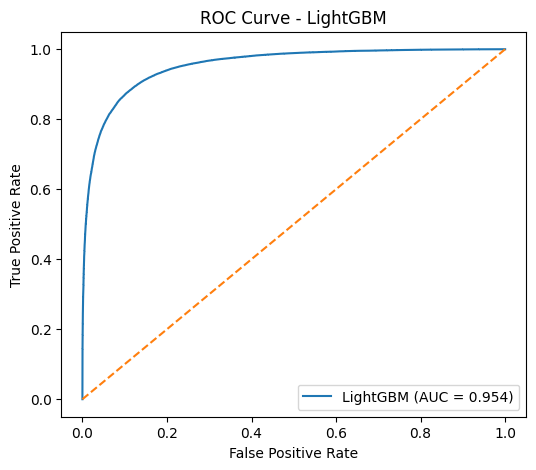

In [26]:
lgb_roc_auc = roc_auc_score(y_test, y_prob_lgb)
print("LightGBM ROC-AUC:", lgb_roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {lgb_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()
plt.show()

LightGBM Precision-Recall AUC: 0.947


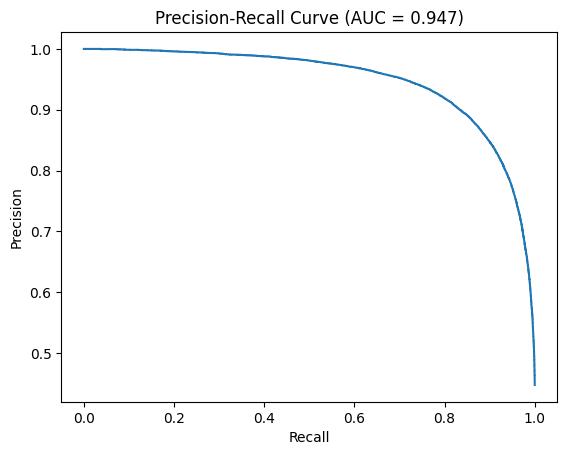

In [27]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_lgb)
pr_auc = auc(recall, precision)
print(f"LightGBM Precision-Recall AUC: {pr_auc:.3f}")

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.3f})")
plt.show()

AMONG ALL MODELS : XGBoost with GRIDSEARCHCV gave the best scores with ROC_AUC SCORE : 0.955.

In [28]:
import joblib
import os 

os.makedirs('models', exist_ok=True)

model_path = os.path.join('models', 'best_xgb_model_roc_0.955_pr-auc_0.948_recall_0.894_f1score_0.875_acc_0.886.pkl')

joblib.dump(best_xgb_clf, model_path)

print("Model saved to:", model_path)

Model saved to: models/best_xgb_model_roc_0.955_pr-auc_0.948_recall_0.894_f1score_0.875_acc_0.886.pkl


TRYING THE BEST MODEL TILL NOW ON THE TEST DATASET.

In [29]:
test_df = pd.read_csv('test.csv')
test_df.head(5)
test_ids = test_df["id"]   
X_test_final = test_df.drop("id", axis=1)
X_test_final = X_test_final[X_train.columns]

In [30]:
best_xgb_clf_loaded = joblib.load(model_path)
y_prob_xgb_loaded = best_xgb_clf_loaded.predict_proba(X_test_final)[:, 1]

best_threshold = 0.41244038939476013
y_pred_xgb_loaded_roc = (y_prob_xgb_loaded >= best_threshold).astype(int)

print("Predictions on Test Set (XGBoost):", y_pred_xgb_loaded_roc)


Predictions on Test Set (XGBoost): [1 0 1 ... 0 0 0]


In [31]:
submission = pd.DataFrame({
    "id": test_ids,
    "Heart disease": y_prob_xgb_loaded  
})

submission.to_csv("submission.csv", index=False)

In [32]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, auc

def evaluate_model(y_test, probs, pred, model_name):

    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall, precision)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, probs),
        "PR-AUC": pr_auc,
        "Precision": precision_score(y_test, pred),
        "Recall (Sensitivity)": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred)
    }

In [33]:
results = []
results.append(evaluate_model(y_test, y_prob_dtc, y_pred_dtc, "Decision Tree"))
results.append(evaluate_model(y_test, y_prob_rfc, y_pred_rfc_roc, "Random Forest"))
results.append(evaluate_model(y_test, y_prob_xgb, y_pred_xgb_roc, "XGBoost"))
results.append(evaluate_model(y_test, y_prob_xgb_best, y_pred_xgb_best_roc, "XGBoost (Tuned)"))
results.append(evaluate_model(y_test, y_prob_lgb, y_pred_lgb_roc, "LightGBM"))

In [1]:
comparison_df = pd.DataFrame(results)

comparison_df.sort_values(by="ROC-AUC", ascending=False)
comparison_df.to_csv("model_comparison.csv", index=False)
comparison_df

NameError: name 'pd' is not defined

In [35]:
!pip install shap

In [36]:
## using SHAP for interpretability of the models
import shap
import matplotlib.pyplot as plt

def shap_analysis(model, X_test, model_name):
    print(f"\nSHAP Analysis for {model_name}")
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # summary Plot
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f"SHAP Summary Plot - {model_name}")
    plt.show()

    # feature Importance (Bar)
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance - {model_name}")
    plt.show()



SHAP Analysis for Decision Tree


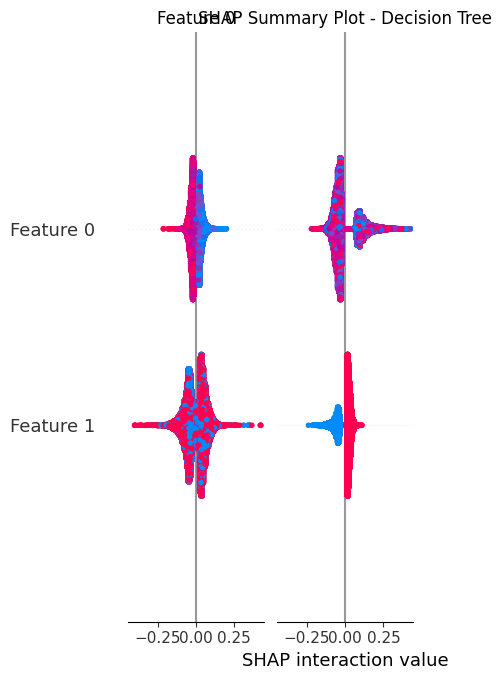

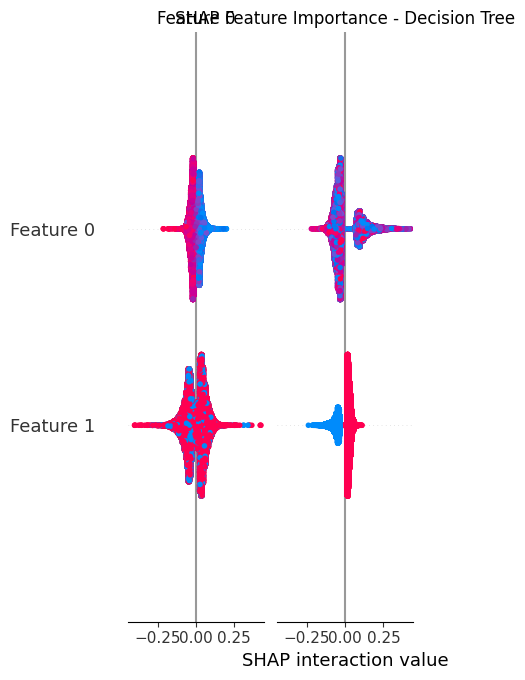

In [ ]:
shap_analysis(dtc, X_test_scaled, "Decision Tree")
shap_analysis(rfc, X_test_scaled, "Random Forest")
shap_analysis(clf_xgb, X_test, "XGBoost")
shap_analysis(best_xgb_clf, X_test, "XGBoost (Tuned)")
shap_analysis(lgb_clf, X_test, "LightGBM")